<a href="https://colab.research.google.com/github/hafzafaryad2-eng/data-analytics/blob/main/lab_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "netflix_titles.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shivamb/netflix-shows",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_359/660811500.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'netflix-shows' dataset.
First 5 records:   show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1

**descriptive analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (df is already loaded from previous cell)

# Display shape
print("Shape of dataset:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of dataset: (8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


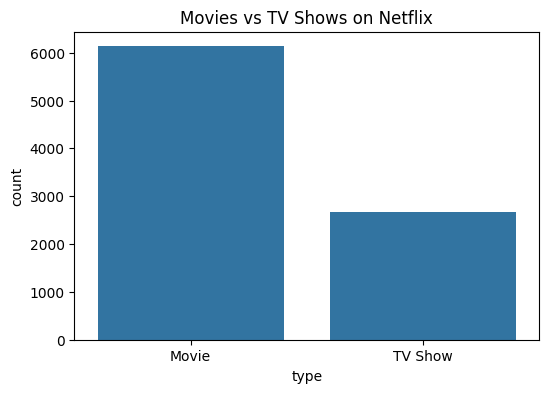

In [ ]:
type_counts = df['type'].value_counts()
print(type_counts)

# Bar chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.show()

In [ ]:
print(df['release_year'].describe())

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


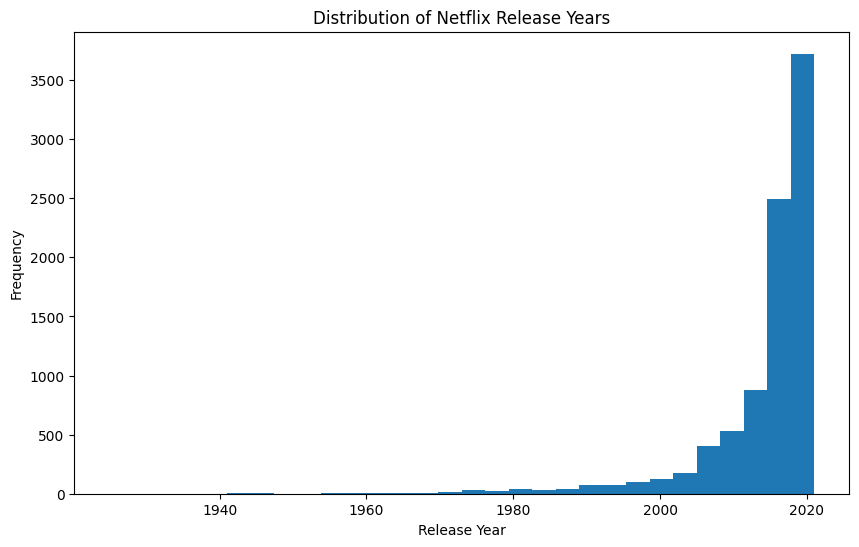

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df['release_year'], bins=30)
plt.title("Distribution of Netflix Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

decade
1920       1
1940      15
1950      11
1960      25
1970      70
1980     129
1990     274
2000     810
2010    5927
2020    1545
Name: count, dtype: int64


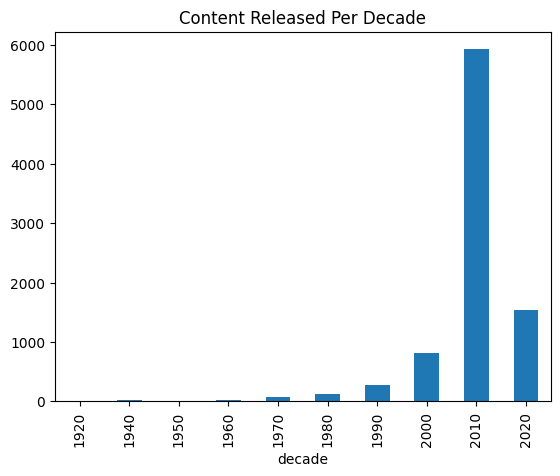

In [ ]:
df['decade'] = (df['release_year']//10)*10
decade_counts = df['decade'].value_counts().sort_index()
print(decade_counts)

decade_counts.plot(kind='bar')
plt.title("Content Released Per Decade")
plt.show()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64


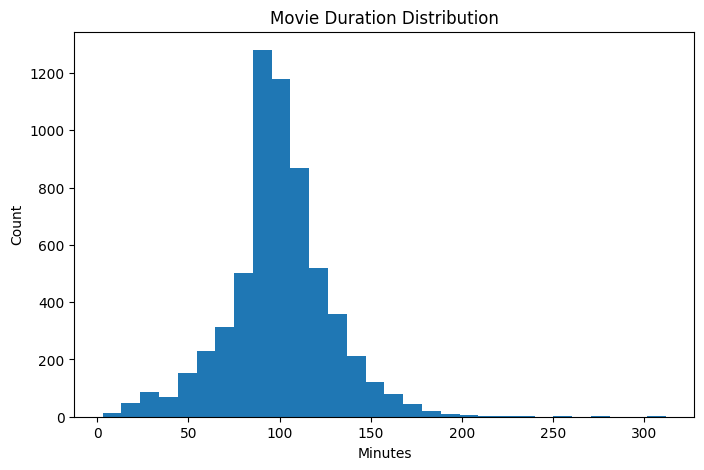

In [ ]:
# Movies duration (extract minutes)
movies = df[df['type']=='Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min','').astype(float)

print(movies['duration_min'].describe())

plt.figure(figsize=(8,5))
plt.hist(movies['duration_min'], bins=30)
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

**diagnostic analysis **

In [ ]:
print(df['rating'].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


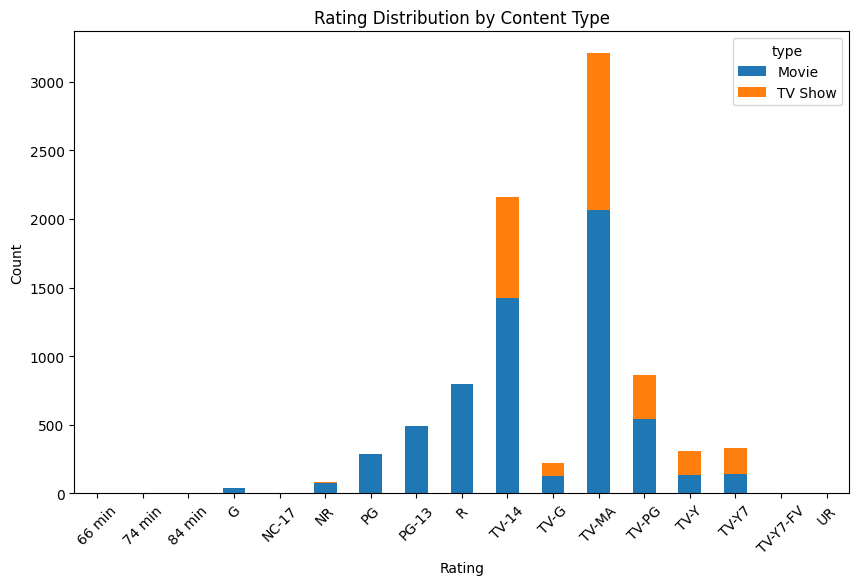

In [ ]:
rating_type = pd.crosstab(df['rating'], df['type'])

rating_type.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Rating Distribution by Content Type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64


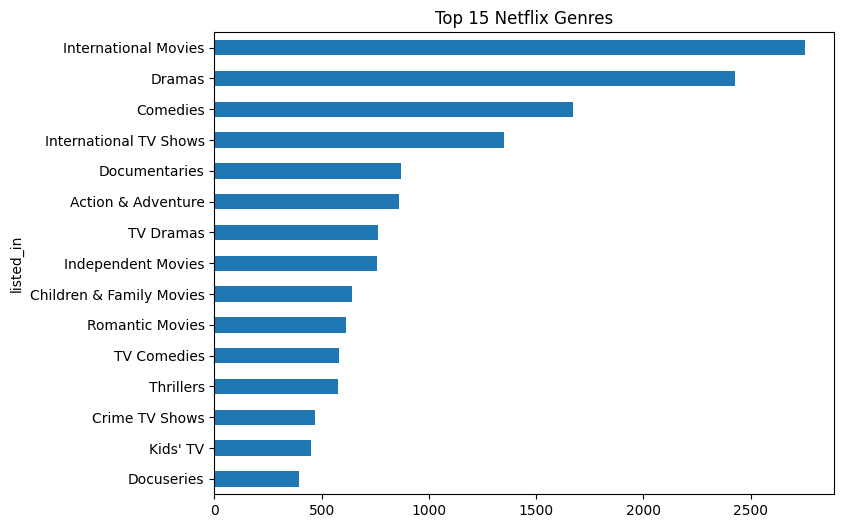

In [ ]:
# Split genres
df['listed_in'] = df['listed_in'].fillna('')
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(15)
print(top_genres)

top_genres.plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Netflix Genres")
plt.gca().invert_yaxis()
plt.show()

country
United States     3689
India             1046
                   833
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


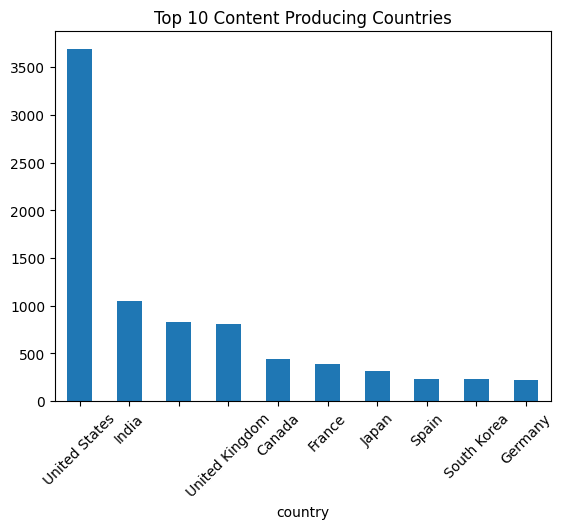

In [ ]:
df['country'] = df['country'].fillna('')
countries = df['country'].str.split(', ').explode()

top_countries = countries.value_counts().head(10)
print(top_countries)

top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xticks(rotation=45)
plt.show()

**ADVANCED INSIGHT ANALYSIS**

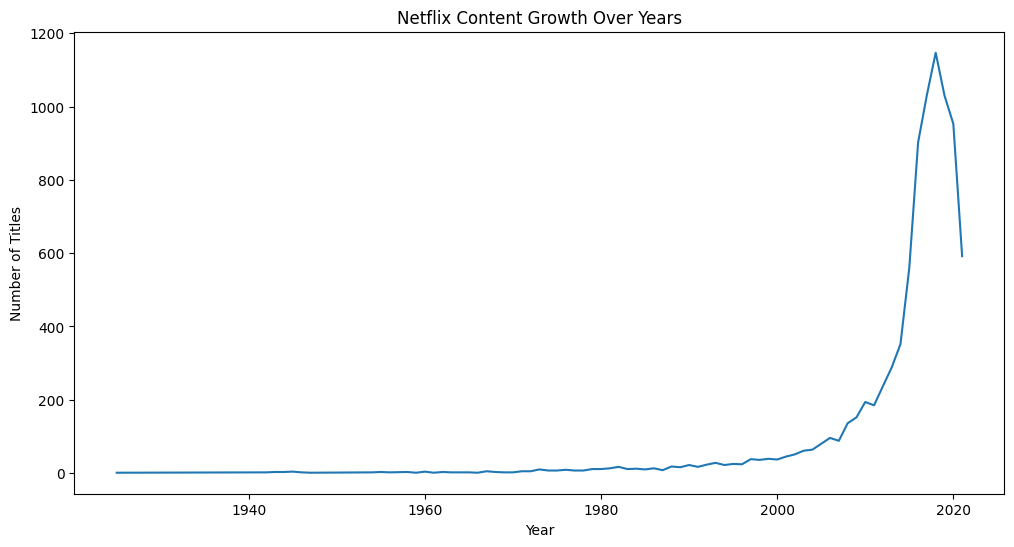

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(year_counts.index, year_counts.values)
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

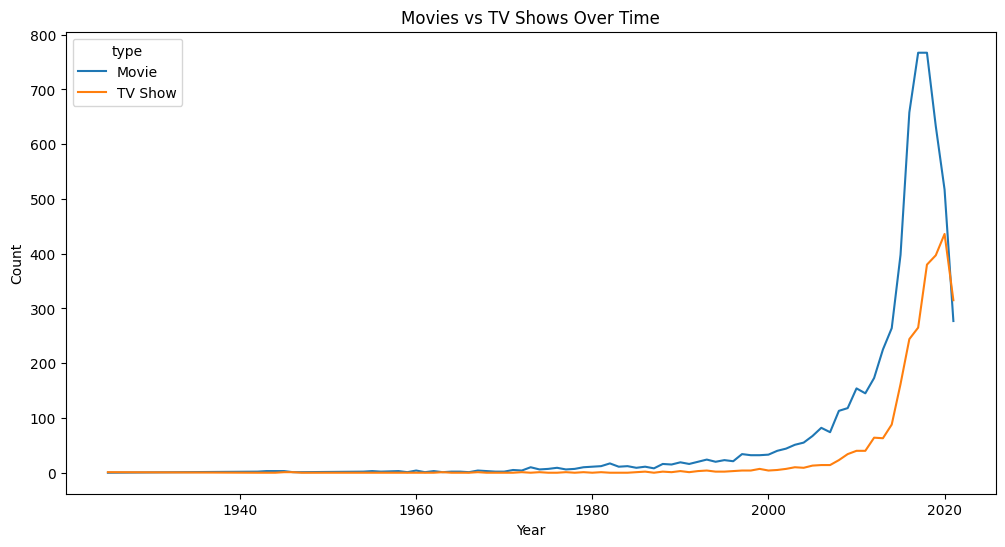

In [ ]:
type_year = pd.crosstab(df['release_year'], df['type'])

type_year.plot(figsize=(12,6))
plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

What does release year histogram reveal?

It shows that most Netflix content was added after 2010, with a massive surge after 2015. This indicates Netflix aggressively expanded its content library during its global expansion phase.

What does rating distribution show?

TV Shows are mostly TV-MA and TV-14, meaning Netflix targets mature and teen audiences heavily. Movies show more rating diversity.

What does genre analysis reveal?

International TV Shows and Dramas dominate, showing Netflix’s focus on global markets and diverse storytelling.

What does country analysis reveal?

United States produces the most content, but India and UK also contribute heavily, indicating international diversification.

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "airbnb_last_review.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ebrahimelgazar/new-york-city-airbnb-market",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_359/3826141563.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'new-york-city-airbnb-market' dataset.
First 5 records:     listing_id    host_name   last_review
0         2595     Jennifer   May 21 2019
1         3831  LisaRoxanne  July 05 2019
2         5099        Chris  June 22 2019
3         5178     Shunichi  June 24 2019
4         5238          Ben  June 09 2019


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (25209, 3)

Columns:
 Index([' listing_id', 'host_name', 'last_review'], dtype='object')

Data Types:
  listing_id     int64
host_name      object
last_review    object
dtype: object

Missing Values:
  listing_id    0
host_name      8
last_review    0
dtype: int64


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "AB_NYC_2019.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dgomonov/new-york-city-airbnb-open-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_359/81088189.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
First 5 records:      id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nig

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (48895, 16)

Columns:
 Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Data Types:
 id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_3

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


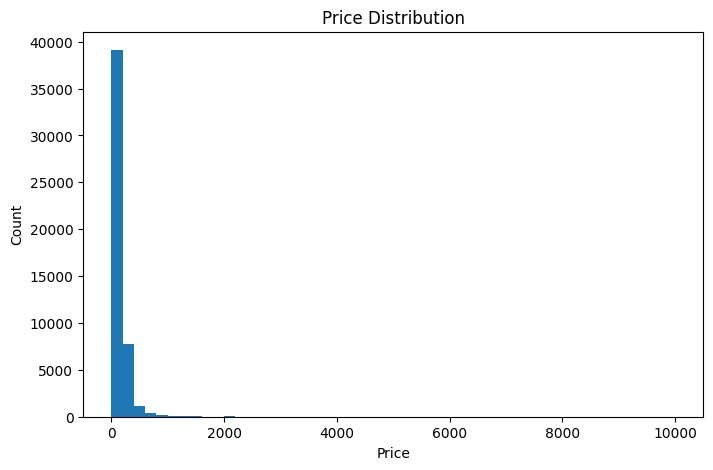

In [ ]:
print(df['price'].describe())

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [ ]:
upper_limit = df['price'].quantile(0.99)
df = df[df['price'] <= upper_limit]

print("New Shape after outlier removal:", df.shape)

New Shape after outlier removal: (48421, 16)


In [ ]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'], drop_first=True)

print(df_encoded.head())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood  latitude  longitude  price  minimum_nights  \
0         John    Kensington  40.64749  -73.97237    149               1   
1     Jennifer       Midtown  40.75362  -73.98377    225               1   
2    Elisabeth        Harlem  40.80902  -73.94190    150               3   
3  LisaRoxanne  Clinton Hill  40.68514  -73.95976     89               1   
4        Laura   East Harlem  40.79851  -73.94399     80              10   

   number_of_reviews last_review  reviews_per_month  \
0                  9  2018-10-19               0.21   
1           

In [ ]:
features = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

# Add encoded columns
encoded_cols = [col for col in df_encoded.columns
                if 'neighbourhood_group_' in col
                or 'room_type_' in col]

X = df_encoded[features + encoded_cols]
y = df_encoded['price']

# Fill missing
X = X.fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge RMSE: 84.24235730920572
Ridge R2: 0.3398992877499901


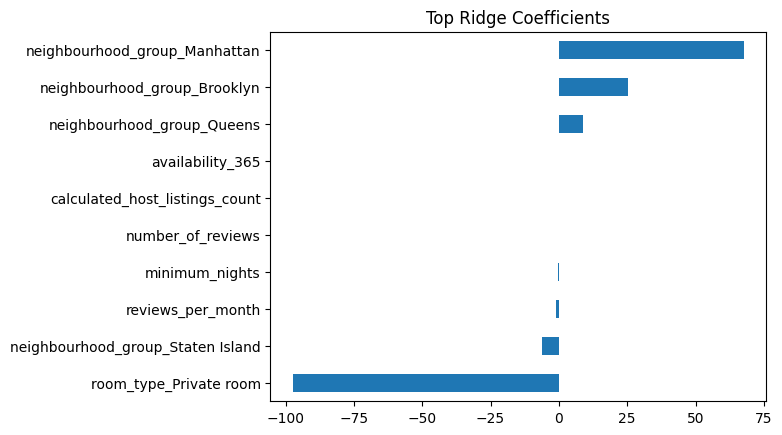

In [ ]:
coef_df = pd.Series(ridge.coef_, index=X.columns)
coef_df.sort_values().tail(10).plot(kind='barh')
plt.title("Top Ridge Coefficients")
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("GBR RMSE:", rmse_gbr)
print("GBR R2:", r2_gbr)

GBR RMSE: 78.14988136004372
GBR R2: 0.43192480595287486


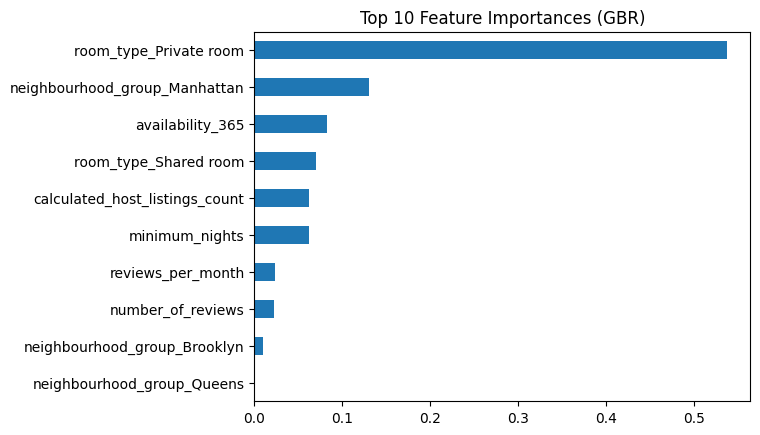

In [ ]:
feat_imp = pd.Series(gbr.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(10).plot(kind='barh')
plt.title("Top 10 Feature Importances (GBR)")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Ridge Regression", "Gradient Boosting"],
    "RMSE": [rmse_ridge, rmse_gbr],
    "R2 Score": [r2_ridge, r2_gbr]
})

print(results)

               Model       RMSE  R2 Score
0   Ridge Regression  84.242357  0.339899
1  Gradient Boosting  78.149881  0.431925


In [ ]:
# Take one example listing
sample = X_test.iloc[[0]].copy()

# Get all room_type columns
room_cols = [col for col in X.columns if 'room_type_' in col]

# Reset room types
sample[room_cols] = 0

predictions = {}

for col in room_cols:
    temp = sample.copy()
    temp[col] = 1
    predictions[col] = ridge.predict(temp)[0]

print(predictions)

{'room_type_Private room': np.float64(104.81499913922936), 'room_type_Shared room': np.float64(75.94850156877898)}


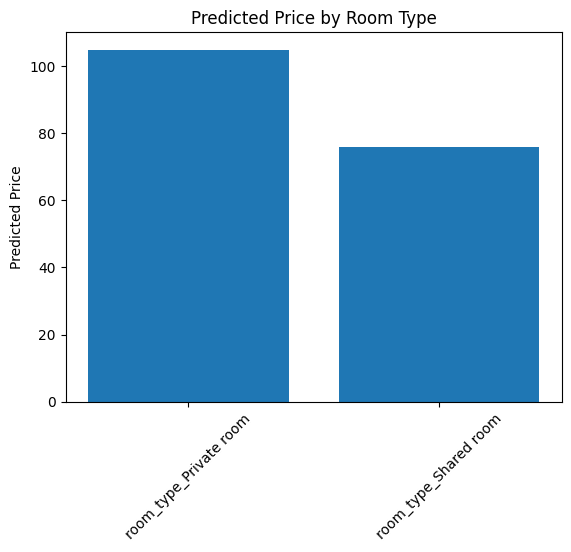

In [ ]:
plt.bar(predictions.keys(), predictions.values())
plt.xticks(rotation=45)
plt.title("Predicted Price by Room Type")
plt.ylabel("Predicted Price")
plt.show()

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "athlete_events.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "heesoo37/120-years-of-olympic-history-athletes-and-results",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_355/3598277847.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 5.43M/5.43M [00:00<00:00, 100MB/s]

Extracting zip of athlete_events.csv...


First 5 records:    ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN  
2        

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (271116, 15)

Columns:
 Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

Data Types:
 ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

Missing Values:
 ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64


In [ ]:
medals = df[df['Medal'].notnull()].copy()
print("Total medal records:", medals.shape[0])


Total medal records: 39783


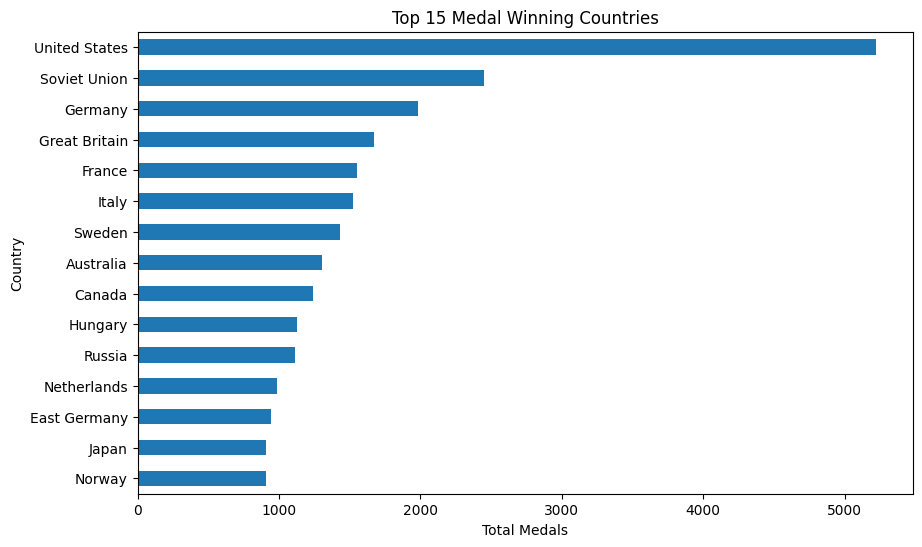

Team
United States    5219
Soviet Union     2451
Germany          1984
Great Britain    1673
France           1550
Italy            1527
Sweden           1434
Australia        1306
Canada           1243
Hungary          1127
Russia           1110
Netherlands       988
East Germany      941
Japan             911
Norway            910
Name: count, dtype: int64


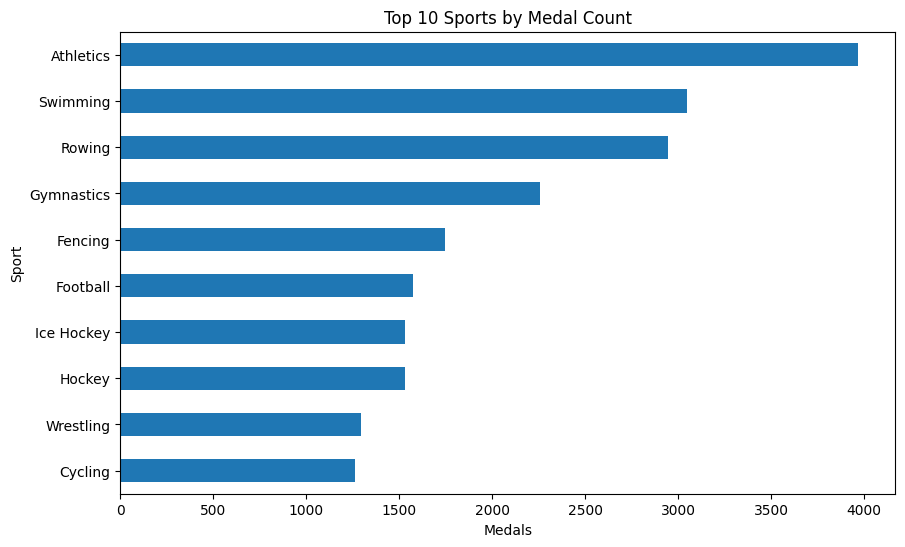

In [ ]:
top_sports = medals['Sport'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_sports.sort_values().plot(kind='barh')
plt.title("Top 10 Sports by Medal Count")
plt.xlabel("Medals")
plt.ylabel("Sport")
plt.show()

/tmp/ipykernel_290/3842493614.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 5.43M/5.43M [00:00<00:00, 88.0MB/s]

Extracting zip of athlete_events.csv...


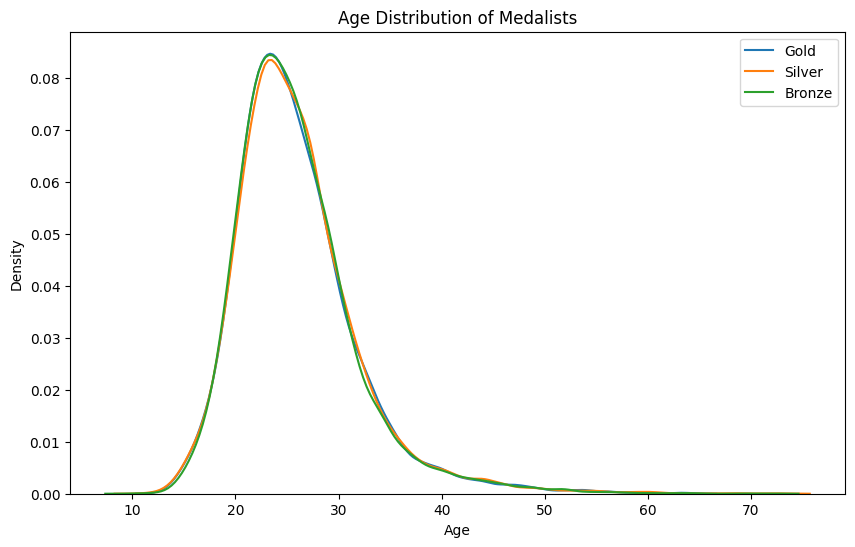

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the dataset directly within this cell if 'df' is not defined
# This ensures the 'df' variable is available for creating 'medals'
file_path = "athlete_events.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "heesoo37/120-years-of-olympic-history-athletes-and-results",
  file_path
)

# Define 'medals' DataFrame
medals = df[df['Medal'].notnull()].copy()

plt.figure(figsize=(10,6))

for medal in ['Gold', 'Silver', 'Bronze']:
    sns.kdeplot(
        medals[medals['Medal'] == medal]['Age'].dropna(),
        label=medal
    )

plt.title("Age Distribution of Medalists")
plt.xlabel("Age")
plt.legend()
plt.show()

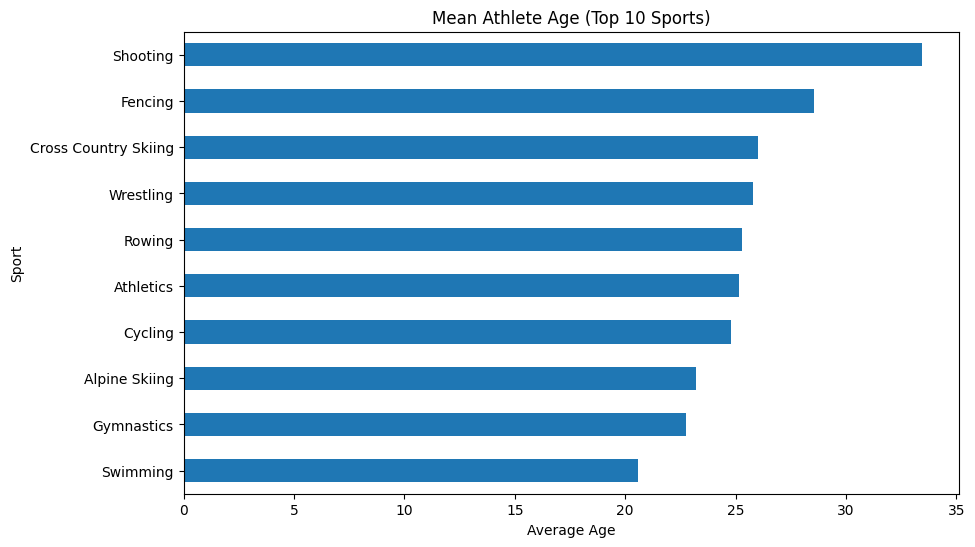

Sport
Swimming                20.566803
Gymnastics              22.733038
Alpine Skiing           23.205462
Cycling                 24.773991
Athletics               25.161223
Rowing                  25.276294
Wrestling               25.798289
Cross Country Skiing    26.006155
Fencing                 28.538822
Shooting                33.422226
Name: Age, dtype: float64


In [ ]:
top10_sports = df['Sport'].value_counts().head(10).index

mean_age = df[df['Sport'].isin(top10_sports)].groupby('Sport')['Age'].mean().sort_values()

plt.figure(figsize=(10,6))
mean_age.plot(kind='barh')
plt.title("Mean Athlete Age (Top 10 Sports)")
plt.xlabel("Average Age")
plt.show()

print(mean_age)

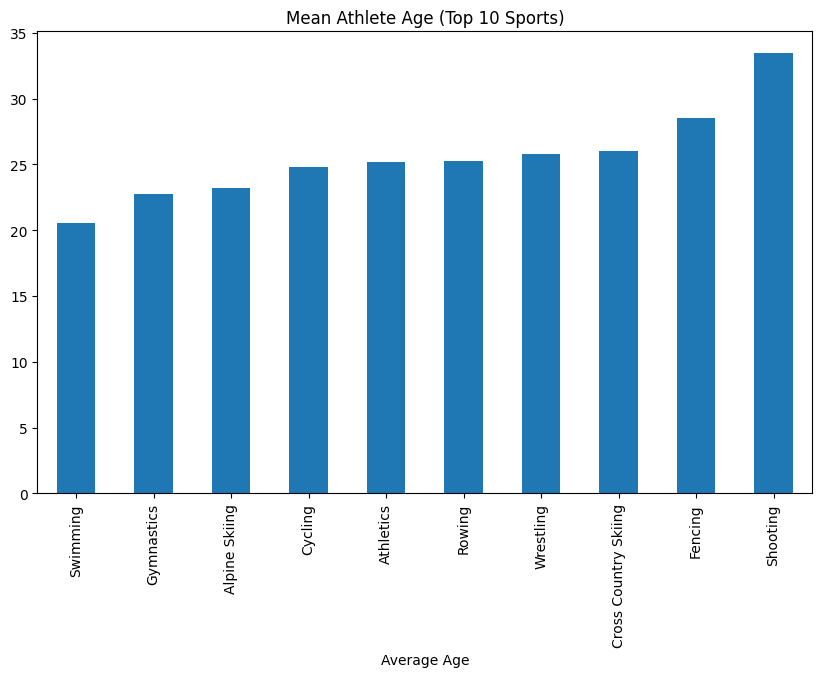

Sport
Swimming                20.566803
Gymnastics              22.733038
Alpine Skiing           23.205462
Cycling                 24.773991
Athletics               25.161223
Rowing                  25.276294
Wrestling               25.798289
Cross Country Skiing    26.006155
Fencing                 28.538822
Shooting                33.422226
Name: Age, dtype: float64


In [ ]:
top10_sports = df['Sport'].value_counts().head(10).index

mean_age = df[df['Sport'].isin(top10_sports)].groupby('Sport')['Age'].mean().sort_values()

plt.figure(figsize=(10,6))
mean_age.plot(kind='bar')
plt.title("Mean Athlete Age (Top 10 Sports)")
plt.xlabel("Average Age")
plt.show()

print(mean_age)

HYPOTHESIS TESTING

In [ ]:
from scipy import stats

male_ages = medals[medals['Sex']=='M']['Age'].dropna()
female_ages = medals[medals['Sex']=='F']['Age'].dropna()

print("Male mean age:", male_ages.mean())
print("Female mean age:", female_ages.mean())

Male mean age: 26.497177781772425
Female mean age: 24.509166963332145


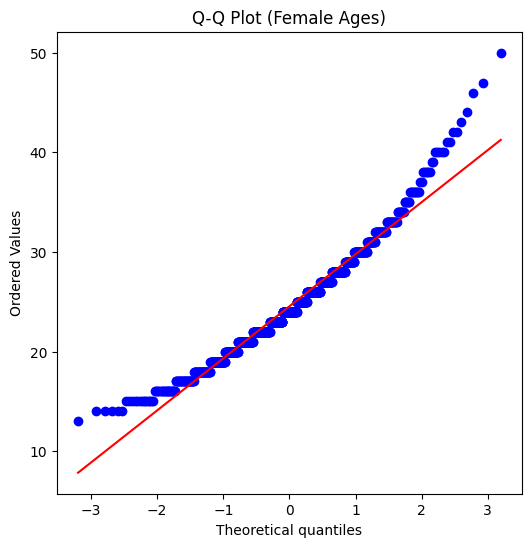

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(female_ages.sample(1000, random_state=42), dist="norm", plot=plt)
plt.title("Q-Q Plot (Female Ages)")
plt.show()

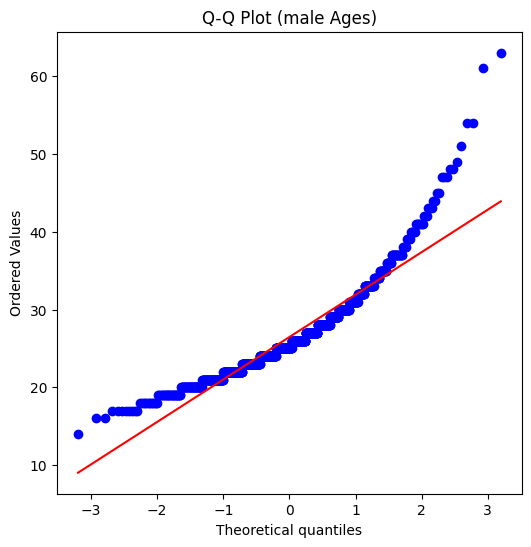

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(male_ages.sample(1000, random_state=42), dist="norm", plot=plt)
plt.title("Q-Q Plot (male Ages)")
plt.show()

In [ ]:
t_stat, p_value = stats.ttest_ind(male_ages, female_ages, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0 → Significant age difference exists.")
else:
    print("Fail to Reject H0 → No significant difference.")

T-Statistic: 32.26954353062455
P-Value: 1.2826547506343631e-223
Reject H0 → Significant age difference exists.


If p-value < 0.05:

"There is a statistically significant difference between male and female medal-winning ages."

If p-value > 0.05:

"There is no statistically significant difference in age between male and female medalists."

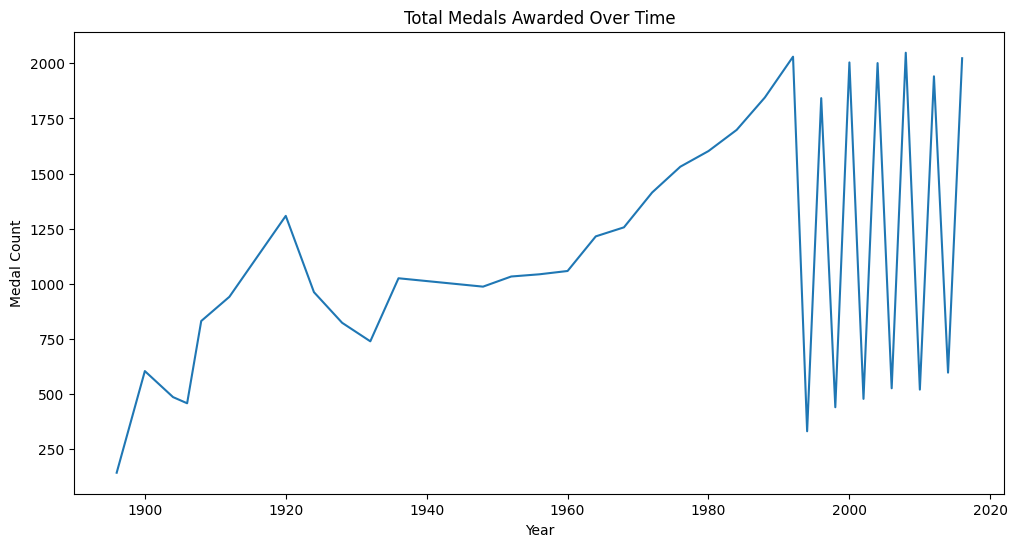

In [ ]:
medals_per_year = medals.groupby('Year').size()

plt.figure(figsize=(12,6))
plt.plot(medals_per_year.index, medals_per_year.values)
plt.title("Total Medals Awarded Over Time")
plt.xlabel("Year")
plt.ylabel("Medal Count")
plt.show()

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Used Car Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rishabhkarn/used-car-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3912/1723851326.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 189k/189k [00:00<00:00, 260kB/s]

First 5 records:    Unnamed: 0                                           car_name  \
0           0                    2017 Mercedes-Benz S-Class S400   
1           1  2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI   
2           2                       2018 BMW X1 sDrive 20d xLine   
3           3                           2019 Kia Seltos GTX Plus   
4           4                    2019 Skoda Superb LK 1.8 TSI AT   

  registration_year insurance_validity fuel_type  seats  kms_driven  \
0            Jul-17      Comprehensive    Petrol      5       56000   
1            Jan-21      Comprehensive    Petrol      5       30615   
2            Sep-18      Comprehensive    Diesel      5       24000   
3            Dec-19      Comprehensive    Petrol      5       18378   
4            Aug-19      Comprehensive    Petrol      5       44900   

    ownsership transmission manufacturing_year  mileage(kmpl)  engine(cc)  \
0  First Owner    Automatic               2017           7.81      299

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1553, 15)

Columns:
 Index(['Unnamed: 0', 'car_name', 'registration_year', 'insurance_validity',
       'fuel_type', 'seats', 'kms_driven', 'ownsership', 'transmission',
       'manufacturing_year', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)',
       'torque(Nm)', 'price(in lakhs)'],
      dtype='object')

Missing Values:
 Unnamed: 0            0
car_name              0
registration_year     0
insurance_validity    0
fuel_type             0
seats                 0
kms_driven            0
ownsership            0
transmission          0
manufacturing_year    0
mileage(kmpl)         3
engine(cc)            3
max_power(bhp)        3
torque(Nm)            4
price(in lakhs)       0
dtype: int64


In [ ]:
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
# The original 'registration_year' column contains entries like 'Jul-17', 'Jan-21', etc.
# The first line extracts the last two characters (e.g., '17', '21').
# The error "ValueError: invalid literal for int() with base 10: 'ce'" indicates that
# after extracting the last two characters, some entries were not numeric (e.g., 'ce').
# This likely happens if the original 'registration_year' had non-standard values
# that didn't end with two digits, or were entirely non-date strings (e.g., 'Finance').

# To fix this, we'll convert the extracted two-character string to a numeric type,
# using 'errors='coerce'' to turn any non-numeric values into NaN (Not a Number).
# Then, we'll add 2000 to get the full year.
df['registration_year_processed'] = pd.to_numeric(df['registration_year'].str[-2:], errors='coerce') + 2000

# After coercing errors, there might be NaN values in 'registration_year_processed'.
# A reasonable imputation for these unparseable registration years is to use the
# 'manufacturing_year' column, which is already an integer year.
# We will fill the NaN values in our new 'registration_year_processed' column with
# the corresponding 'manufacturing_year' values.
df['registration_year'] = df['registration_year_processed'].fillna(df['manufacturing_year'])

# Drop the temporary column
df = df.drop(columns=['registration_year_processed'])

In [ ]:
df = df.dropna()

In [ ]:
df_encoded = pd.get_dummies(df,
                            columns=['fuel_type', 'transmission', 'ownsership'],
                            drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WineQT.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3912/1628802049.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 76.2k/76.2k [00:00<00:00, 273kB/s]

First 5 records:    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8       

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

Dataset Shape: (1143, 13)

Column Names:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   f

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [ ]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000         

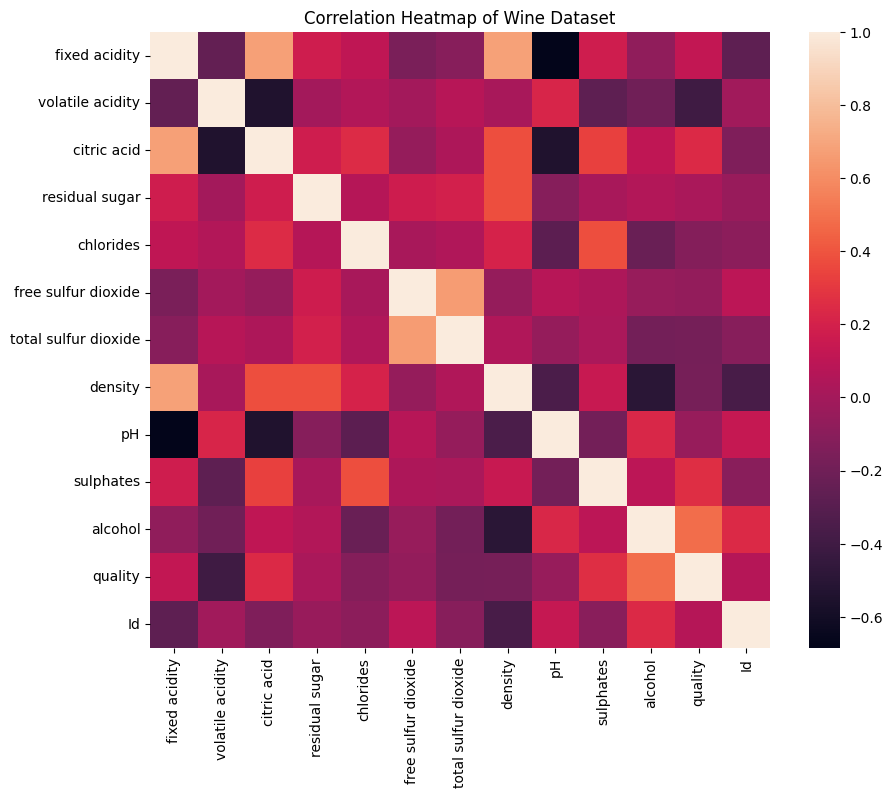

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)

plt.title("Correlation Heatmap of Wine Dataset")
plt.show()

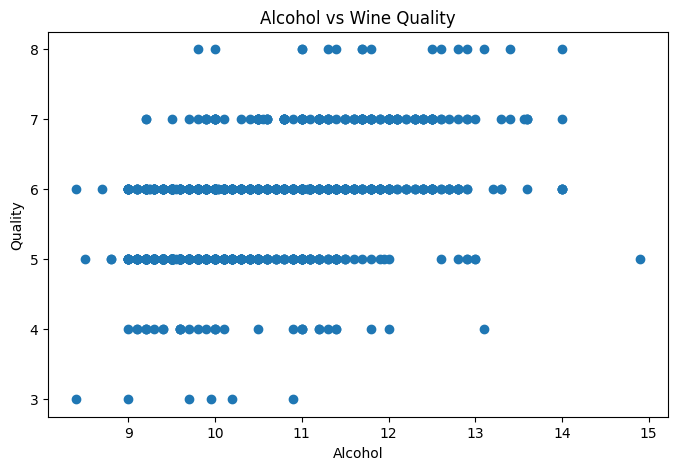

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["alcohol"], df["quality"])

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")

plt.show()

In [ ]:
avg_alcohol = df.groupby("quality")["alcohol"].mean()

print("Average Alcohol by Quality:")
print(avg_alcohol)

Average Alcohol by Quality:
quality
3     9.691667
4    10.260606
5     9.902277
6    10.655339
7    11.482634
8    11.937500
Name: alcohol, dtype: float64


In [ ]:
df["quality_level"] = np.where(df["quality"] >= 7, "High", "Low")

print(df[["quality", "quality_level"]].head())

   quality quality_level
0        5           Low
1        5           Low
2        5           Low
3        6           Low
4        5           Low


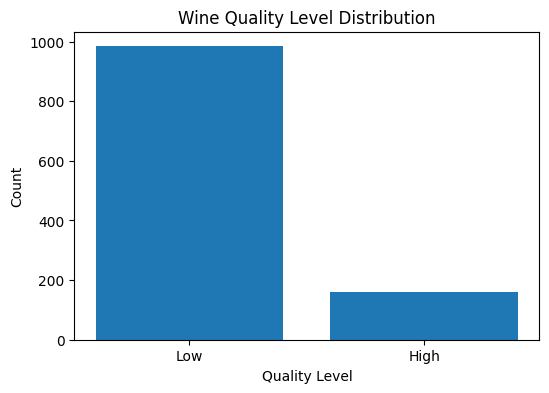

In [ ]:
quality_counts = df["quality_level"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(quality_counts.index, quality_counts.values)

plt.title("Wine Quality Level Distribution")
plt.xlabel("Quality Level")
plt.ylabel("Count")

plt.show()

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Reviews.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "arhamrumi/amazon-product-reviews",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3912/624819089.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 115M/115M [00:06<00:00, 18.0MB/s]

Extracting zip of Reviews.csv...


First 5 records:    Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

Dataset Shape: (568454, 10)

Column Names:
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [ ]:
  print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [ ]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
                  Id  HelpfulnessNumerator  HelpfulnessDenominator  \
count  568454.000000         568454.000000            568454.00000   
mean   284227.500000              1.743817                 2.22881   
std    164098.679298              7.636513                 8.28974   
min         1.000000              0.000000                 0.00000   
25%    142114.250000              0.000000                 0.00000   
50%    284227.500000              0.000000                 1.00000   
75%    426340.750000              2.000000                 2.00000   
max    568454.000000            866.000000               923.00000   

               Score          Time  
count  568454.000000  5.684540e+05  
mean        4.183199  1.296257e+09  
std         1.310436  4.804331e+07  
min         1.000000  9.393408e+08  
25%         4.000000  1.271290e+09  
50%         5.000000  1.311120e+09  
75%         5.000000  1.332720e+09  
max         5.000000  1.351210e+09  


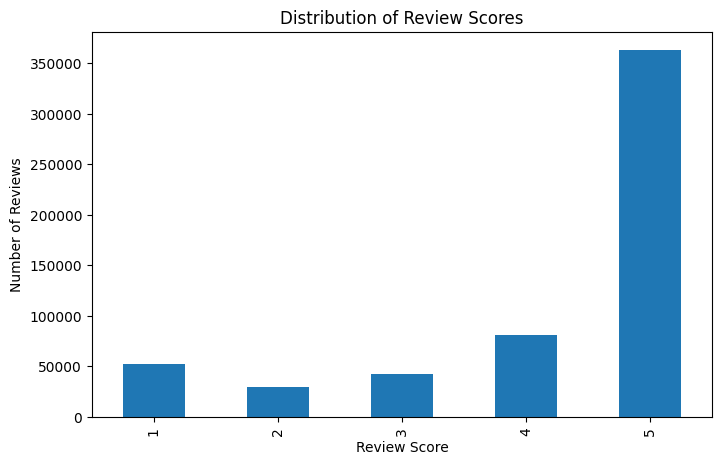

In [ ]:
plt.figure(figsize=(8,5))

df["Score"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
df["helpful_ratio"] = df["HelpfulnessNumerator"] / (df["HelpfulnessDenominator"] + 1)

print(df[["HelpfulnessNumerator","HelpfulnessDenominator","helpful_ratio"]].head())

   HelpfulnessNumerator  HelpfulnessDenominator  helpful_ratio
0                     1                       1           0.50
1                     0                       0           0.00
2                     1                       1           0.50
3                     3                       3           0.75
4                     0                       0           0.00


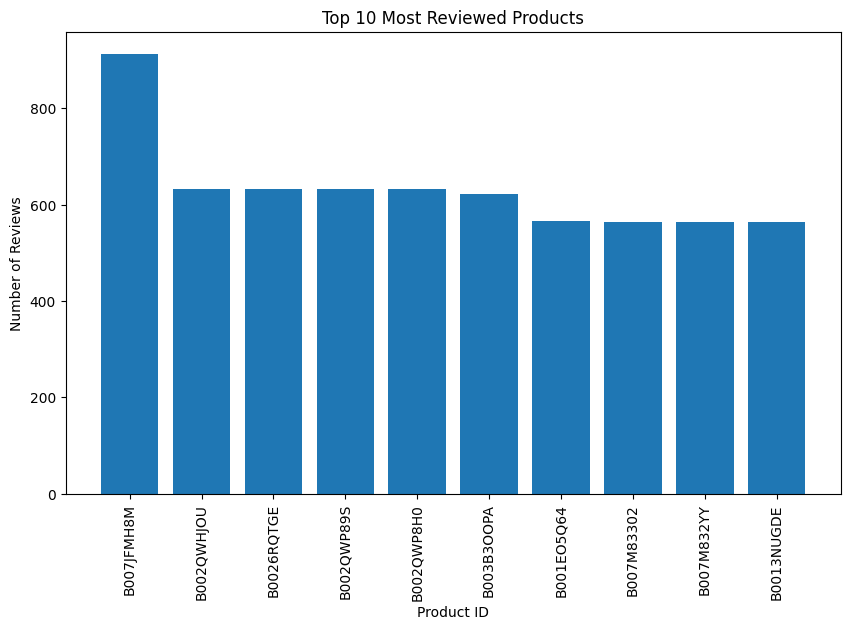

In [ ]:
top_products = df["ProductId"].value_counts().head(10)

plt.figure(figsize=(10,6))

plt.bar(top_products.index, top_products.values)

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=90)

plt.show()

In [ ]:
df["date"] = pd.to_datetime(df["Time"], unit="s")

print(df[["Time","date"]].head())

         Time       date
0  1303862400 2011-04-27
1  1346976000 2012-09-07
2  1219017600 2008-08-18
3  1307923200 2011-06-13
4  1350777600 2012-10-21


In [ ]:
avg_score = df.groupby("ProductId")["Score"].mean().sort_values(ascending=False)

print("Top Products by Average Score:")
print(avg_score.head())

Top Products by Average Score:
ProductId
B009WVB40S    5.0
B009PG8MVO    5.0
B009PFJUF2    5.0
B009PCDDO4    5.0
B009OY38SY    5.0
Name: Score, dtype: float64


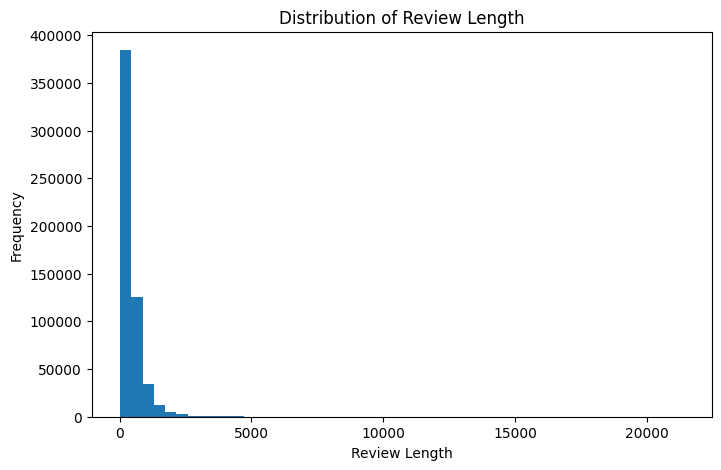

In [ ]:
df["review_length"] = df["Text"].str.len()

plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins=50)

plt.title("Distribution of Review Length")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "student_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "devansodariya/student-performance-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3912/2104719694.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 41.0k/41.0k [00:00<00:00, 966kB/s]

First 5 records:   school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

Dataset Shape: (395, 33)

Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [ ]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
std   

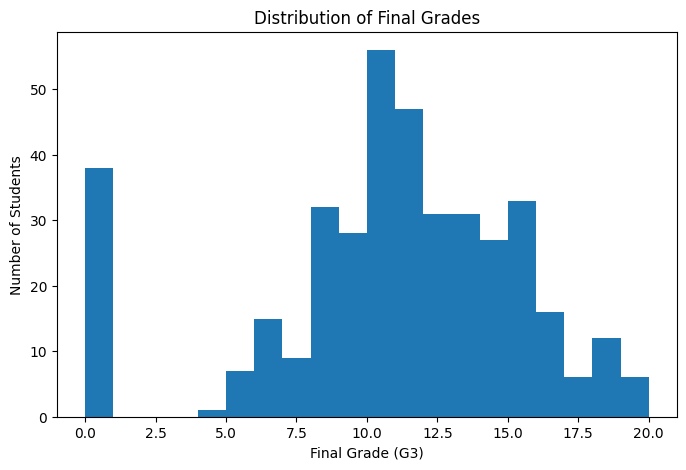

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["G3"], bins=20)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
avg_grade = df.groupby("sex")["G3"].mean()

print("Average Grade by Gender:")
print(avg_grade)

Average Grade by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


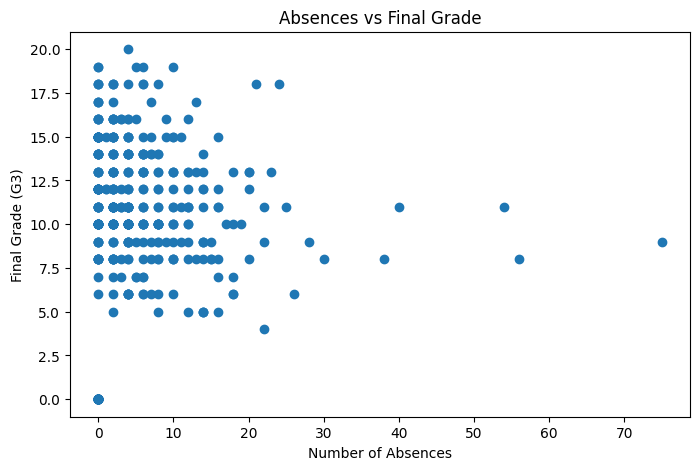

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["absences"], df["G3"])

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")

plt.show()

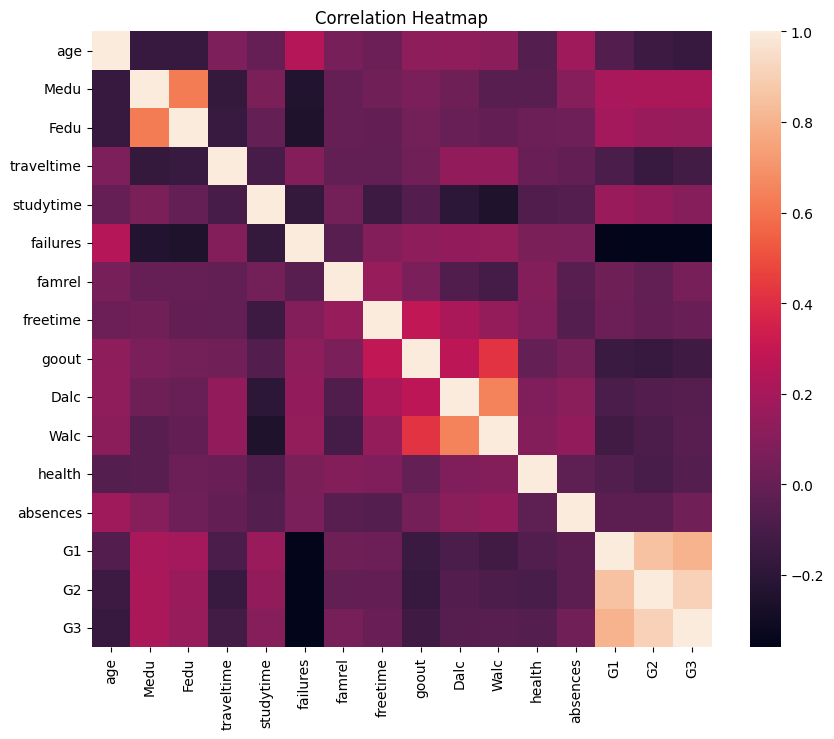

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), annot=False)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
top_students = df.sort_values(by="G3", ascending=False).head(10)

print("Top Students:")
print(top_students[["school","sex","age","G1","G2","G3"]])

Top Students:
    school sex  age  G1  G2  G3
47      GP   M   16  19  19  20
286     GP   F   18  18  18  19
374     MS   F   18  19  18  19
110     GP   M   15  18  19  19
8       GP   M   15  16  18  19
113     GP   M   15  18  19  19
91      GP   F   15  16  17  18
42      GP   M   15  19  18  18
36      GP   M   15  15  16  18
104     GP   M   15  16  18  18


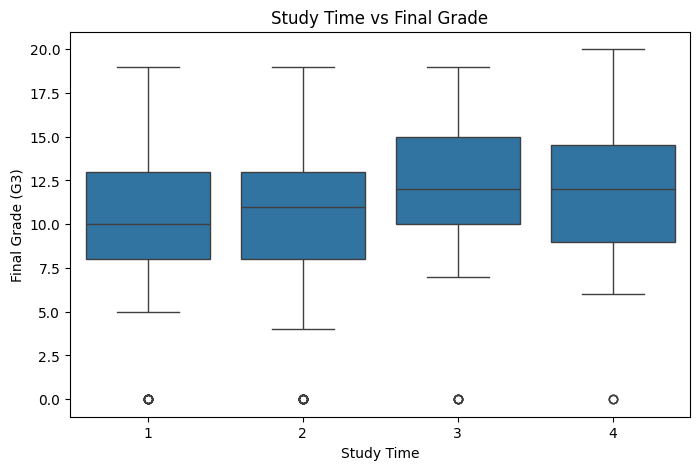

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["studytime"], y=df["G3"])

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")

plt.show()